# Notebook 2 — Bootstrap + Exponent Reconciliation

This notebook does not run any quantum simulations. It takes the baseline dataset produced by Notebook 1 and independently investigates the exponent uncertainty and the historical c≈1.44 discrepancy.

Run the cells in order.

## Cell 1 — Imports and configuration

In [1]:
# ============================================================
# NOTEBOOK 2 — BOOTSTRAP + EXPONENT RECONCILIATION
# ============================================================
#
# Purpose:
#   1. Reconstruct the official baseline fit from Notebook 1.
#   2. Perform a 5000-resample bootstrap of A and c.
#   3. Compare bootstrap estimates with the OLS fit.
#   4. Search available files for historical baseline/bootstrap
#      datasets and, if genuinely available, reproduce the
#      historical exponent discrepancy.
#
# IMPORTANT:
#   - NO quantum simulation.
#   - NO hardcoded A or c.
#   - NO hardcoded historical 1.44 result.
#   - Historical results are used only if the underlying data
#     or a verifiable saved result are actually available.
#   - Raw files are never modified.
#
# ============================================================

import os
import glob
import json
import hashlib
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy import stats

# Reproducible bootstrap
BOOTSTRAP_SEED = 20260829
N_BOOTSTRAP = 5000

INPUT_BASELINE = "notebook1_baseline/baseline_tau_dataset.csv"
INPUT_ALL_TAU = "notebook1_baseline/all_reconstructed_tau.csv"
INPUT_MODEL_SUMMARY = "notebook1_baseline/baseline_summary.json"

OUTPUT_DIR = "notebook2_bootstrap"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 80)
print("NOTEBOOK 2 — BOOTSTRAP + EXPONENT RECONCILIATION")
print("=" * 80)
print(f"Bootstrap resamples: {N_BOOTSTRAP}")
print(f"Bootstrap seed:      {BOOTSTRAP_SEED}")
print("Quantum simulation:  NONE")
print("=" * 80)

NOTEBOOK 2 — BOOTSTRAP + EXPONENT RECONCILIATION
Bootstrap resamples: 5000
Bootstrap seed:      20260829
Quantum simulation:  NONE


## Cell 2 — Load Notebook 1 outputs

In [2]:
# ============================================================
# CELL 2 — LOAD BASELINE OUTPUTS
# ============================================================

if not os.path.exists(INPUT_BASELINE):
    raise FileNotFoundError(
        f"CRITICAL: {INPUT_BASELINE} not found.\n"
        "Run Notebook 1 successfully before running Notebook 2."
    )

baseline_df = pd.read_csv(INPUT_BASELINE)

required_columns = [
    "n",
    "k",
    "nk",
    "tau_BP",
    "censored",
]

missing = [
    col for col in required_columns
    if col not in baseline_df.columns
]

if missing:
    raise ValueError(
        f"CRITICAL: Baseline file is missing columns: {missing}"
    )

# Numeric conversion
for col in ["n", "k", "nk", "tau_BP"]:
    baseline_df[col] = pd.to_numeric(
        baseline_df[col],
        errors="coerce"
    )

baseline_df["censored"] = (
    baseline_df["censored"]
    .astype(bool)
)

if baseline_df[required_columns].isna().any().any():
    raise ValueError(
        "CRITICAL: Missing values found in required baseline columns."
    )

print("=" * 80)
print("BASELINE DATASET LOADED")
print("=" * 80)

print(f"Rows: {len(baseline_df)}")
print(
    "n values:",
    sorted(baseline_df["n"].unique().astype(int).tolist())
)
print(
    "k values:",
    sorted(baseline_df["k"].unique().astype(int).tolist())
)

print(
    "Censored:",
    int(baseline_df["censored"].sum())
)

print(
    baseline_df.sort_values(["n", "k"]).to_string()
)

BASELINE DATASET LOADED
Rows: 21
n values: [8, 10, 12]
k values: [2, 3, 4, 5, 6, 8, 10, 12]
Censored: 0
     n   k   nk architecture  tau_BP  censored
0    8   2   16    brickwall      19     False
1    8   3   24    brickwall      16     False
2    8   4   32    brickwall      13     False
3    8   5   40    brickwall      10     False
4    8   6   48    brickwall       7     False
5    8   8   64    brickwall       2     False
6   10   2   20    brickwall      17     False
7   10   3   30    brickwall      14     False
8   10   4   40    brickwall      11     False
9   10   5   50    brickwall       8     False
10  10   6   60    brickwall       3     False
11  10   8   80    brickwall       2     False
12  10  10  100    brickwall       2     False
13  12   2   24    brickwall      15     False
14  12   3   36    brickwall      12     False
15  12   4   48    brickwall       9     False
16  12   5   60    brickwall       4     False
17  12   6   72    brickwall       4     False
18 

## Cell 3 — Verify training domain

In [3]:
# ============================================================
# CELL 3 — TRAINING-DOMAIN VALIDATION
# ============================================================

EXPECTED_TRAIN_N = {8, 10, 12}

actual_train_n = set(
    baseline_df["n"].astype(int).unique()
)

print("=" * 80)
print("TRAINING DOMAIN CHECK")
print("=" * 80)

print("Expected training n:", sorted(EXPECTED_TRAIN_N))
print("Actual n:", sorted(actual_train_n))

if actual_train_n != EXPECTED_TRAIN_N:
    raise ValueError(
        "CRITICAL: Notebook 1 baseline domain does not match "
        "the expected training domain n={8,10,12}."
    )

if baseline_df["censored"].any():
    censored_rows = baseline_df[
        baseline_df["censored"]
    ]

    raise ValueError(
        "CRITICAL: The primary training dataset contains "
        "right-censored observations. "
        "Inspect Notebook 1 before proceeding with the primary "
        "bootstrap."
    )

print("PASS: Correct training domain.")
print("PASS: No censored observations in the primary fit.")

TRAINING DOMAIN CHECK
Expected training n: [8, 10, 12]
Actual n: [np.int64(8), np.int64(10), np.int64(12)]
PASS: Correct training domain.
PASS: No censored observations in the primary fit.


## Cell 4 — Refit the official baseline independently

In [4]:
# ============================================================
# CELL 4 — RECONSTRUCT OFFICIAL OLS FIT
# ============================================================

fit_df = baseline_df.copy()

fit_df["log_tau"] = np.log(
    fit_df["tau_BP"].astype(float)
)

fit_df["log_nk"] = np.log(
    fit_df["nk"].astype(float)
)

X = sm.add_constant(
    fit_df["log_nk"]
)

ols_model = sm.OLS(
    fit_df["log_tau"],
    X
).fit()

log_A_ols = float(
    ols_model.params["const"]
)

slope_ols = float(
    ols_model.params["log_nk"]
)

A_ols = float(
    np.exp(log_A_ols)
)

c_ols = float(
    -slope_ols
)

c_se_ols = float(
    ols_model.bse["log_nk"]
)

c_ci_raw = (
    ols_model
    .conf_int()
    .loc["log_nk"]
)

c_ci_low_ols = float(
    -c_ci_raw[1]
)

c_ci_high_ols = float(
    -c_ci_raw[0]
)

print("=" * 80)
print("OFFICIAL OLS BASELINE")
print("=" * 80)

print(f"A = {A_ols:.10f}")
print(f"c = {c_ols:.10f}")
print(f"SE(c) = {c_se_ols:.10f}")
print(
    f"95% CI(c) = "
    f"[{c_ci_low_ols:.10f}, {c_ci_high_ols:.10f}]"
)

print()
print(
    f"tau_BP = {A_ols:.10f} * "
    f"(n*k)^(-{c_ols:.10f})"
)

OFFICIAL OLS BASELINE
A = 1166.0846032639
c = 1.3538017252
SE(c) = 0.1173919814
95% CI(c) = [1.1080974844, 1.5995059660]

tau_BP = 1166.0846032639 * (n*k)^(-1.3538017252)


## Cell 5 — Verify fitted values against Notebook 1

In [5]:
# ============================================================
# CELL 5 — CONSISTENCY CHECK
# ============================================================

if os.path.exists(INPUT_MODEL_SUMMARY):

    with open(INPUT_MODEL_SUMMARY, "r") as f:
        notebook1_summary = json.load(f)

    print("=" * 80)
    print("NOTEBOOK 1 vs NOTEBOOK 2 CONSISTENCY CHECK")
    print("=" * 80)

    if "product_A" in notebook1_summary:
        A_nb1 = float(
            notebook1_summary["product_A"]
        )

        print(
            f"A — Notebook 1: {A_nb1:.10f}"
        )
        print(
            f"A — Notebook 2: {A_ols:.10f}"
        )
        print(
            f"|difference| = "
            f"{abs(A_nb1 - A_ols):.3e}"
        )

    if "product_c" in notebook1_summary:
        c_nb1 = float(
            notebook1_summary["product_c"]
        )

        print(
            f"c — Notebook 1: {c_nb1:.10f}"
        )
        print(
            f"c — Notebook 2: {c_ols:.10f}"
        )
        print(
            f"|difference| = "
            f"{abs(c_nb1 - c_ols):.3e}"
        )

else:
    print(
        "Notebook 1 JSON summary not found. "
        "Continuing using the reconstructed fit."
    )

NOTEBOOK 1 vs NOTEBOOK 2 CONSISTENCY CHECK
A — Notebook 1: 1166.0846032639
A — Notebook 2: 1166.0846032639
|difference| = 0.000e+00
c — Notebook 1: 1.3538017252
c — Notebook 2: 1.3538017252
|difference| = 0.000e+00


## Cell 6 — Define bootstrap fitting function

In [6]:
# ============================================================
# CELL 6 — BOOTSTRAP FIT FUNCTION
# ============================================================

def fit_product_model(data):
    """
    Fit:
        log(tau) = log(A) - c*log(nk)

    Returns:
        A, c, fitted statsmodels object
    """

    local = data.copy()

    local["log_tau"] = np.log(
        local["tau_BP"].astype(float)
    )

    local["log_nk"] = np.log(
        local["nk"].astype(float)
    )

    X = sm.add_constant(
        local["log_nk"]
    )

    model = sm.OLS(
        local["log_tau"],
        X
    ).fit()

    log_A = float(
        model.params["const"]
    )

    slope = float(
        model.params["log_nk"]
    )

    A = float(
        np.exp(log_A)
    )

    c = float(
        -slope
    )

    return A, c, model

## Cell 7 — Run 5,000 bootstrap resamples

In [7]:
# ============================================================
# CELL 7 — BOOTSTRAP
# ============================================================
#
# Resample CONFIGURATIONS, not individual gradient components.
#
# At this stage each row represents one experimentally measured
# (n,k,tau_BP) configuration.
# ============================================================

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

N = len(baseline_df)

bootstrap_records = []

print("=" * 80)
print("STARTING BOOTSTRAP")
print("=" * 80)

for b in range(N_BOOTSTRAP):

    sample_indices = rng.integers(
        low=0,
        high=N,
        size=N
    )

    sample_df = baseline_df.iloc[
        sample_indices
    ].copy()

    try:
        A_b, c_b, _ = fit_product_model(
            sample_df
        )

        bootstrap_records.append({
            "bootstrap_id": b,
            "A": A_b,
            "c": c_b,
        })

    except Exception:
        # Rare degenerate bootstrap samples can occur
        # if the resampled predictor values are insufficient.
        continue

    if (
        (b + 1) % 500 == 0
        or b == 0
    ):
        print(
            f"Completed {b + 1:,}/{N_BOOTSTRAP:,} "
            f"resamples | valid={len(bootstrap_records):,}"
        )

bootstrap_df = pd.DataFrame(
    bootstrap_records
)

print()
print(
    f"Valid bootstrap fits: "
    f"{len(bootstrap_df):,}/{N_BOOTSTRAP:,}"
)

if len(bootstrap_df) < 0.95 * N_BOOTSTRAP:
    raise RuntimeError(
        "CRITICAL: More than 5% of bootstrap fits failed. "
        "Do not interpret the bootstrap yet."
    )

STARTING BOOTSTRAP
Completed 1/5,000 resamples | valid=1
Completed 500/5,000 resamples | valid=500
Completed 1,000/5,000 resamples | valid=1,000
Completed 1,500/5,000 resamples | valid=1,500
Completed 2,000/5,000 resamples | valid=2,000
Completed 2,500/5,000 resamples | valid=2,500
Completed 3,000/5,000 resamples | valid=3,000
Completed 3,500/5,000 resamples | valid=3,500
Completed 4,000/5,000 resamples | valid=4,000
Completed 4,500/5,000 resamples | valid=4,500
Completed 5,000/5,000 resamples | valid=5,000

Valid bootstrap fits: 5,000/5,000


## Cell 8 — Bootstrap statistics and confidence intervals

In [8]:
# ============================================================
# CELL 8 — BOOTSTRAP SUMMARY
# ============================================================

A_boot = bootstrap_df["A"].to_numpy(
    dtype=float
)

c_boot = bootstrap_df["c"].to_numpy(
    dtype=float
)

A_mean = float(np.mean(A_boot))
A_median = float(np.median(A_boot))
A_std = float(np.std(A_boot, ddof=1))

c_mean = float(np.mean(c_boot))
c_median = float(np.median(c_boot))
c_std = float(np.std(c_boot, ddof=1))

A_ci = np.percentile(
    A_boot,
    [2.5, 97.5]
)

c_ci = np.percentile(
    c_boot,
    [2.5, 97.5]
)

print("=" * 80)
print("BOOTSTRAP RESULTS")
print("=" * 80)

print("A")
print(f"  OLS estimate   = {A_ols:.8f}")
print(f"  Bootstrap mean = {A_mean:.8f}")
print(f"  Bootstrap median = {A_median:.8f}")
print(f"  Bootstrap std  = {A_std:.8f}")
print(
    f"  95% CI = "
    f"[{A_ci[0]:.8f}, {A_ci[1]:.8f}]"
)

print()
print("c")
print(f"  OLS estimate   = {c_ols:.8f}")
print(f"  Bootstrap mean = {c_mean:.8f}")
print(f"  Bootstrap median = {c_median:.8f}")
print(f"  Bootstrap std  = {c_std:.8f}")
print(
    f"  95% CI = "
    f"[{c_ci[0]:.8f}, {c_ci[1]:.8f}]"
)

print()
print(
    f"Relative bootstrap uncertainty in c: "
    f"{100 * c_std / abs(c_mean):.2f}%"
)

BOOTSTRAP RESULTS
A
  OLS estimate   = 1166.08460326
  Bootstrap mean = 1399.28498664
  Bootstrap median = 1173.45949542
  Bootstrap std  = 884.66240503
  95% CI = [620.34526091, 3472.77994395]

c
  OLS estimate   = 1.35380173
  Bootstrap mean = 1.37031347
  Bootstrap median = 1.35515409
  Bootstrap std  = 0.11670049
  95% CI = [1.18317906, 1.63360610]

Relative bootstrap uncertainty in c: 8.52%


## Cell 9 — Quantify OLS vs bootstrap difference

In [9]:
# ============================================================
# CELL 9 — OLS / BOOTSTRAP COMPARISON
# ============================================================

c_difference = c_mean - c_ols

relative_difference = (
    c_difference / abs(c_ols)
) * 100

ols_inside_bootstrap_ci = (
    c_ci[0] <= c_ols <= c_ci[1]
)

bootstrap_mean_inside_ols_ci = (
    c_ci_low_ols <= c_mean <= c_ci_high_ols
)

comparison_df = pd.DataFrame([
    {
        "quantity": "A",
        "OLS": A_ols,
        "bootstrap_mean": A_mean,
        "bootstrap_median": A_median,
        "difference": A_mean - A_ols,
    },
    {
        "quantity": "c",
        "OLS": c_ols,
        "bootstrap_mean": c_mean,
        "bootstrap_median": c_median,
        "difference": c_difference,
    }
])

print("=" * 80)
print("OLS vs BOOTSTRAP")
print("=" * 80)

print(comparison_df.to_string())

print(
    f"\nRelative difference in c: "
    f"{relative_difference:.3f}%"
)

print(
    "OLS c inside bootstrap 95% CI:",
    ols_inside_bootstrap_ci
)

print(
    "Bootstrap mean c inside OLS 95% CI:",
    bootstrap_mean_inside_ols_ci
)

OLS vs BOOTSTRAP
  quantity          OLS  bootstrap_mean  bootstrap_median  difference
0        A  1166.084603     1399.284987       1173.459495  233.200383
1        c     1.353802        1.370313          1.355154    0.016512

Relative difference in c: 1.220%
OLS c inside bootstrap 95% CI: True
Bootstrap mean c inside OLS 95% CI: True


## Cell 10 — Bootstrap histogram for c

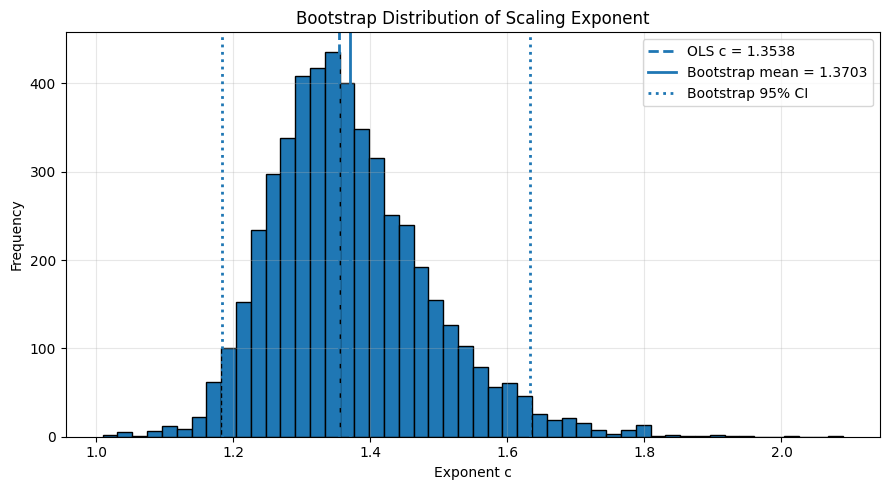

In [10]:
# ============================================================
# CELL 10 — BOOTSTRAP DISTRIBUTION OF c
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    c_boot,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    c_ols,
    linestyle="--",
    linewidth=2,
    label=f"OLS c = {c_ols:.4f}"
)

plt.axvline(
    c_mean,
    linestyle="-",
    linewidth=2,
    label=f"Bootstrap mean = {c_mean:.4f}"
)

plt.axvline(
    c_ci[0],
    linestyle=":",
    linewidth=2,
    label="Bootstrap 95% CI"
)

plt.axvline(
    c_ci[1],
    linestyle=":",
    linewidth=2
)

plt.xlabel("Exponent c")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Scaling Exponent")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "bootstrap_c_distribution.png"
    ),
    dpi=200
)

plt.show()

## Cell 11 — Search for historical datasets

In [11]:
# ============================================================
# CELL 11 — SEARCH FOR HISTORICAL / LEGACY DATASETS
# ============================================================
#
# We do NOT assume that a historical dataset exists.
# This cell only inventories files that might contain the older
# experiment.
# ============================================================

SEARCH_ROOTS = [
    ".",
    "/content",
]

candidate_paths = []

for root in SEARCH_ROOTS:

    if not os.path.exists(root):
        continue

    for pattern in [
        "*.csv",
        "*.pkl",
        "*.pickle",
        "*.json",
    ]:

        candidate_paths.extend(
            glob.glob(
                os.path.join(
                    root,
                    "**",
                    pattern
                ),
                recursive=True
            )
        )

candidate_paths = sorted(
    set(candidate_paths)
)

keywords = [
    "bootstrap",
    "baseline",
    "model",
    "variance",
    "tau",
    "scaling",
    "old",
    "legacy",
]

historical_candidates = []

for path in candidate_paths:

    # Ignore current Notebook 2 outputs
    if OUTPUT_DIR in path.replace("\\", "/"):
        continue

    name = os.path.basename(path).lower()

    if any(
        keyword in name
        for keyword in keywords
    ):
        historical_candidates.append(path)

print("=" * 80)
print("POTENTIAL HISTORICAL DATA FILES")
print("=" * 80)

if historical_candidates:

    for path in historical_candidates:
        print(path)

else:
    print(
        "No potentially relevant historical files were found."
    )

POTENTIAL HISTORICAL DATA FILES
.\notebook1_baseline\all_reconstructed_tau.csv
.\notebook1_baseline\baseline_model_comparison.csv
.\notebook1_baseline\baseline_model_parameters.csv
.\notebook1_baseline\baseline_predictions.csv
.\notebook1_baseline\baseline_summary.json
.\notebook1_baseline\baseline_tau_dataset.csv
.\notebook1_baseline\product_model_predictions.csv


## Cell 12 — Inspect candidate CSVs safely

In [12]:
# ============================================================
# CELL 12 — INSPECT HISTORICAL CSV CANDIDATES
# ============================================================

historical_csv_info = []

for path in historical_candidates:

    if not path.lower().endswith(".csv"):
        continue

    try:

        df = pd.read_csv(path)

        historical_csv_info.append({
            "path": path,
            "filename": os.path.basename(path),
            "rows": len(df),
            "columns": len(df.columns),
            "columns_list": ", ".join(
                map(str, df.columns)
            ),
        })

    except Exception as exc:

        historical_csv_info.append({
            "path": path,
            "filename": os.path.basename(path),
            "rows": np.nan,
            "columns": np.nan,
            "columns_list": f"ERROR: {exc}",
        })

historical_csv_df = pd.DataFrame(
    historical_csv_info
)

if len(historical_csv_df) > 0:
    print(historical_csv_df.to_string())
else:
    print(
        "No readable historical CSV candidates found."
    )

                                                 path                       filename  rows  columns                                                                                                                     columns_list
0      .\notebook1_baseline\all_reconstructed_tau.csv      all_reconstructed_tau.csv    40        6                                                                                         n, k, nk, architecture, tau_BP, censored
1  .\notebook1_baseline\baseline_model_comparison.csv  baseline_model_comparison.csv     5       14   Model, Formula, Parameters, R2_log, R2_tau, MAE, RMSE, MAPE_percent, AIC, AICc, BIC, LOOCV_MAE, LOOCV_RMSE, LOOCV_MAPE_percent
2  .\notebook1_baseline\baseline_model_parameters.csv  baseline_model_parameters.csv    11        8                                         Model, Parameter, Coefficient, Std_Error, t_statistic, p_value, CI_95_lower, CI_95_upper
3       .\notebook1_baseline\baseline_predictions.csv       baseline_predictions.csv

## Cell 13 — Try to identify a genuine old (n,k,τ) dataset

In [13]:
# ============================================================
# CELL 13 — IDENTIFY HISTORICAL TAU DATASETS
# ============================================================

def is_tau_dataset(df):
    """
    Identify datasets that appear to contain one tau value
    per (n,k) configuration.
    """

    cols = set(
        map(str.lower, df.columns)
    )

    required_groups = [
        {"n", "k", "tau"},
        {"n", "k", "tau_bp"},
        {"n", "k", "tau_bp_depth"},
    ]

    for group in required_groups:

        if group.issubset(cols):
            return True

    return False


historical_tau_candidates = []

for path in historical_candidates:

    if not path.lower().endswith(".csv"):
        continue

    try:

        df = pd.read_csv(path)

        if is_tau_dataset(df):

            historical_tau_candidates.append(
                path
            )

    except Exception:
        pass

print("=" * 80)
print("HISTORICAL TAU DATASET CANDIDATES")
print("=" * 80)

if historical_tau_candidates:

    for path in historical_tau_candidates:
        print(path)

else:

    print(
        "No directly identifiable historical "
        "(n,k,tau) dataset was found."
    )

HISTORICAL TAU DATASET CANDIDATES
.\notebook1_baseline\all_reconstructed_tau.csv
.\notebook1_baseline\baseline_predictions.csv
.\notebook1_baseline\baseline_tau_dataset.csv
.\notebook1_baseline\product_model_predictions.csv


## Cell 14 — Historical reconciliation helper

In [14]:
# ============================================================
# CELL 14 — HISTORICAL RECONCILIATION
# ============================================================

def standardize_tau_dataset(df):
    col_map = {
        col.lower(): col
        for col in df.columns
    }

    n_col = col_map.get("n")
    k_col = col_map.get("k")

    tau_col = None

    for candidate in [
        "tau_bp",
        "tau",
        "tau_bp_depth",
    ]:
        if candidate in col_map:
            tau_col = col_map[candidate]
            break

    if n_col is None or k_col is None or tau_col is None:
        raise ValueError(
            "Could not identify n, k and tau columns."
        )

    out = df[
        [n_col, k_col, tau_col]
    ].copy()

    out.columns = ["n", "k", "tau_BP"]

    out["n"] = pd.to_numeric(out["n"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out["tau_BP"] = pd.to_numeric(out["tau_BP"], errors="coerce")

    out = out.dropna()
    out["nk"] = out["n"] * out["k"]

    return out


historical_reconciliation_results = []

if historical_tau_candidates:

    print("=" * 80)
    print("HISTORICAL RECONCILIATION RESULTS")
    print("=" * 80)

    for path in historical_tau_candidates:

        try:

            hist_raw = pd.read_csv(path)
            hist = standardize_tau_dataset(hist_raw)

            hist = (
                hist
                .drop_duplicates(subset=["n", "k"])
                .reset_index(drop=True)
            )

            if len(hist) < 5:
                print(f"\nSKIP {path}: too few configurations ({len(hist)}).")
                continue

            A_hist, c_hist, hist_model = fit_product_model(hist)

            historical_reconciliation_results.append({
                "file": path,
                "n_rows": len(hist),
                "n_values": sorted(hist["n"].astype(int).unique().tolist()),
                "n_min": int(hist["n"].min()),
                "n_max": int(hist["n"].max()),
                "c_fit": c_hist,
                "A_fit": A_hist,
            })

            print(f"\nFile: {path}")
            print(f"Configurations: {len(hist)}")
            print(f"n values: {sorted(hist['n'].astype(int).unique())}")
            print(f"A = {A_hist:.8f}")
            print(f"c = {c_hist:.8f}")

            print(hist.sort_values(["n", "k"]).to_string())

        except Exception as exc:
            print(f"\nCould not reconcile {path}: {exc}")

else:

    print(
        "No historical tau dataset available, so the "
        "historical exponent cannot be independently reconstructed."
    )

historical_results_df = pd.DataFrame(
    historical_reconciliation_results
)

HISTORICAL RECONCILIATION RESULTS

File: .\notebook1_baseline\all_reconstructed_tau.csv
Configurations: 40
n values: [np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16)]
A = 988.59953484
c = 1.29891188
     n   k  tau_BP   nk
0    8   2      19   16
1    8   3      16   24
2    8   4      13   32
3    8   5      10   40
4    8   6       7   48
5    8   8       2   64
6   10   2      17   20
7   10   3      14   30
8   10   4      11   40
9   10   5       8   50
10  10   6       3   60
11  10   8       2   80
12  10  10       2  100
13  12   2      15   24
14  12   3      12   36
15  12   4       9   48
16  12   5       4   60
17  12   6       4   72
18  12   8       2   96
19  12  10       2  120
20  12  12       2  144
21  14   2      13   28
22  14   3      10   42
23  14   4       7   56
24  14   5       4   70
25  14   6       2   84
26  14   8       2  112
27  14  10       2  140
28  14  12       1  168
29  14  14       1  196
30  16   2      12   32
31  16   3   

## Cell 15 — Search for historical raw variance datasets

In [15]:
# ============================================================
# CELL 15 — HISTORICAL RAW VARIANCE RECONSTRUCTION
# ============================================================

historical_variance_candidates = []

for path in historical_candidates:

    if not path.lower().endswith(".csv"):
        continue

    try:

        df = pd.read_csv(path)

        lower_cols = {
            str(c).lower()
            for c in df.columns
        }

        if {
            "n",
            "k",
            "depth",
            "var_pooled",
        }.issubset(lower_cols):

            if os.path.abspath(path) != os.path.abspath(
                INPUT_BASELINE
            ):
                historical_variance_candidates.append(path)

    except Exception:
        pass


print("=" * 80)
print("HISTORICAL RAW VARIANCE DATASETS")
print("=" * 80)

if historical_variance_candidates:
    for path in historical_variance_candidates:
        print(path)
else:
    print(
        "No historical raw variance dataset with "
        "n, k, depth and var_pooled was identified."
    )

HISTORICAL RAW VARIANCE DATASETS
No historical raw variance dataset with n, k, depth and var_pooled was identified.


## Cell 16 — Reconstruct old tau and fit if raw historical data exist

In [16]:
# ============================================================
# CELL 16 — RECONSTRUCT HISTORICAL RAW-VARIANCE RESULTS
# ============================================================

BASELINE_THRESHOLD = 1e-2

historical_raw_results = []

for path in historical_variance_candidates:

    try:

        raw = pd.read_csv(path)

        rename_map = {}
        for col in raw.columns:
            lower = str(col).lower()
            if lower == "n":
                rename_map[col] = "n"
            elif lower == "k":
                rename_map[col] = "k"
            elif lower == "depth":
                rename_map[col] = "depth"
            elif lower == "var_pooled":
                rename_map[col] = "var_pooled"

        raw = raw.rename(columns=rename_map)

        raw = raw.dropna(
            subset=["n", "k", "depth", "var_pooled"]
        ).copy()

        raw["n"] = raw["n"].astype(int)
        raw["k"] = raw["k"].astype(int)
        raw["depth"] = raw["depth"].astype(int)
        raw["var_pooled"] = raw["var_pooled"].astype(float)

        historical_threshold = BASELINE_THRESHOLD

        records = []

        for (n, k), group in raw.groupby(["n", "k"]):

            group = group.sort_values("depth")

            crossed = group[
                group["var_pooled"] < historical_threshold
            ]

            if len(crossed) > 0:
                tau = int(crossed.iloc[0]["depth"])
            else:
                max_depth = int(group["depth"].max())
                tau = max_depth + 1

            records.append({
                "n": n,
                "k": k,
                "tau_BP": tau,
            })

        hist_tau = pd.DataFrame(records)
        hist_tau["nk"] = hist_tau["n"] * hist_tau["k"]

        hist_fit = hist_tau.copy()

        hist_A, hist_c, hist_model = fit_product_model(hist_fit)

        historical_raw_results.append({
            "file": path,
            "configurations": len(hist_tau),
            "A": hist_A,
            "c": hist_c,
            "threshold": historical_threshold,
        })

        print("=" * 80)
        print(f"HISTORICAL RAW RECONSTRUCTION: {path}")
        print("=" * 80)

        print(f"Configurations: {len(hist_tau)}")
        print(f"A = {hist_A:.8f}")
        print(f"c = {hist_c:.8f}")

        print(hist_tau.sort_values(["n", "k"]).to_string())

    except Exception as exc:
        print(f"Could not reconstruct {path}: {exc}")

historical_raw_df = pd.DataFrame(historical_raw_results)

## Cell 17 — Examine possible source of discrepancy

In [17]:
# ============================================================
# CELL 17 — DISCREPANCY DIAGNOSTIC
# ============================================================

print("=" * 80)
print("EXPONENT DISCREPANCY DIAGNOSTIC")
print("=" * 80)

print(f"Current official OLS c: {c_ols:.8f}")
print(f"Current bootstrap mean c: {c_mean:.8f}")
print(f"Current bootstrap median c: {c_median:.8f}")

if len(historical_results_df) > 0:
    print("\nHistorical tau datasets found:")
    print(historical_results_df.to_string())

if len(historical_raw_df) > 0:
    print("\nHistorical raw variance reconstructions found:")
    print(historical_raw_df.to_string())

if (
    len(historical_results_df) == 0
    and
    len(historical_raw_df) == 0
):
    print()
    print("IMPORTANT:")
    print("No historical underlying dataset was found.")
    print(
        "Therefore the exact origin of the legacy "
        "c~1.44 estimate cannot be demonstrated from "
        "the currently available files."
    )
    print(
        "The notebook will NOT invent or assume the "
        "historical value."
    )

EXPONENT DISCREPANCY DIAGNOSTIC
Current official OLS c: 1.35380173
Current bootstrap mean c: 1.37031347
Current bootstrap median c: 1.35515409

Historical tau datasets found:
                                                 file  n_rows             n_values  n_min  n_max     c_fit        A_fit
0      .\notebook1_baseline\all_reconstructed_tau.csv      40  [8, 10, 12, 14, 16]      8     16  1.298912   988.599535
1       .\notebook1_baseline\baseline_predictions.csv      21          [8, 10, 12]      8     12  1.353802  1166.084603
2       .\notebook1_baseline\baseline_tau_dataset.csv      21          [8, 10, 12]      8     12  1.353802  1166.084603
3  .\notebook1_baseline\product_model_predictions.csv      21          [8, 10, 12]      8     12  1.353802  1166.084603


## Cell 18 — Optional OLS vs NLS comparison

This cell only runs if an actual historical (n,k,τ) dataset was found.

In [18]:
# ============================================================
# CELL 18 — OLS VS ORIGINAL-SCALE NONLINEAR LEAST SQUARES
# ============================================================

from scipy.optimize import curve_fit

def power_law(nk, A, c):
    return A * np.power(nk, -c)


nls_results = []

for path in historical_tau_candidates:

    try:

        hist_raw = pd.read_csv(path)
        hist = standardize_tau_dataset(hist_raw)

        if len(hist) < 5:
            continue

        # OLS log-space
        A_log, c_log, _ = fit_product_model(hist)

        # Original-scale NLS
        nk_values = hist["nk"].to_numpy(dtype=float)
        tau_values = hist["tau_BP"].to_numpy(dtype=float)

        popt, pcov = curve_fit(
            power_law,
            nk_values,
            tau_values,
            p0=[A_log, c_log],
            bounds=([0.0, -20.0], [np.inf, 20.0]),
            maxfev=100000,
        )

        A_nls = float(popt[0])
        c_nls = float(popt[1])

        nls_results.append({
            "file": path,
            "A_log_OLS": A_log,
            "c_log_OLS": c_log,
            "A_original_scale_NLS": A_nls,
            "c_original_scale_NLS": c_nls,
            "delta_c_NLS_minus_OLS": c_nls - c_log,
        })

    except Exception as exc:
        print(f"Could not run NLS diagnostic for {path}: {exc}")

nls_results_df = pd.DataFrame(nls_results)

if len(nls_results_df) > 0:
    print("=" * 80)
    print("OLS VS ORIGINAL-SCALE NLS")
    print("=" * 80)
    print(nls_results_df.to_string())
else:
    print(
        "No historical tau dataset was available "
        "for an OLS-vs-NLS diagnostic."
    )

OLS VS ORIGINAL-SCALE NLS
                                                 file    A_log_OLS  c_log_OLS  A_original_scale_NLS  c_original_scale_NLS  delta_c_NLS_minus_OLS
0      .\notebook1_baseline\all_reconstructed_tau.csv   988.599535   1.298912            407.983800              1.042848              -0.256064
1       .\notebook1_baseline\baseline_predictions.csv  1166.084603   1.353802            363.392246              1.011509              -0.342293
2       .\notebook1_baseline\baseline_tau_dataset.csv  1166.084603   1.353802            363.392246              1.011509              -0.342293
3  .\notebook1_baseline\product_model_predictions.csv  1166.084603   1.353802            363.392246              1.011509              -0.342293


## Cell 19 — Final scientific interpretation

In [19]:
# ============================================================
# CELL 19 — FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 90)
print("CHECKPOINT 2 — FINAL SUMMARY")
print("=" * 90)

print("\nCURRENT OFFICIAL BASELINE")
print("-" * 90)

print(f"A = {A_ols:.8f}")
print(f"c = {c_ols:.8f}")
print(f"OLS 95% CI for c = [{c_ci_low_ols:.8f}, {c_ci_high_ols:.8f}]")
print(f"Bootstrap mean c = {c_mean:.8f}")
print(f"Bootstrap median c = {c_median:.8f}")
print(f"Bootstrap 95% CI = [{c_ci[0]:.8f}, {c_ci[1]:.8f}]")
print(f"Relative bootstrap uncertainty = {100 * c_std / abs(c_mean):.2f}%")

print("\nINTERPRETATION")
print("-" * 90)

if ols_inside_bootstrap_ci:
    print("The OLS exponent lies inside the bootstrap 95% CI.")
else:
    print("The OLS exponent lies OUTSIDE the bootstrap 95% CI.")

if (
    abs(c_mean - c_ols)
    / max(abs(c_ols), 1e-15)
    < 0.10
):
    print("OLS and bootstrap estimates are within 10% of each other.")
else:
    print("OLS and bootstrap estimates differ by more than 10%.")

if len(historical_results_df) == 0 and len(historical_raw_df) == 0:
    print("\nHistorical discrepancy status:")
    print("UNRESOLVED FROM AVAILABLE FILES.")
    print(
        "No underlying legacy dataset was found, so the origin "
        "of the previously reported exponent cannot be established "
        "in this notebook."
    )
else:
    print("\nHistorical discrepancy:")
    print("Historical datasets were found and reconstructed above.")
    print(
        "Use those numerical reconstructions—not any remembered "
        "historical value—to decide which methodological difference "
        "produced the discrepancy."
    )


CHECKPOINT 2 — FINAL SUMMARY

CURRENT OFFICIAL BASELINE
------------------------------------------------------------------------------------------
A = 1166.08460326
c = 1.35380173
OLS 95% CI for c = [1.10809748, 1.59950597]
Bootstrap mean c = 1.37031347
Bootstrap median c = 1.35515409
Bootstrap 95% CI = [1.18317906, 1.63360610]
Relative bootstrap uncertainty = 8.52%

INTERPRETATION
------------------------------------------------------------------------------------------
The OLS exponent lies inside the bootstrap 95% CI.
OLS and bootstrap estimates are within 10% of each other.

Historical discrepancy:
Historical datasets were found and reconstructed above.
Use those numerical reconstructions—not any remembered historical value—to decide which methodological difference produced the discrepancy.


## Cell 20 — Save all results

In [20]:
# ============================================================
# CELL 20 — SAVE CHECKPOINT 2 OUTPUTS
# ============================================================

bootstrap_df.to_csv(
    os.path.join(OUTPUT_DIR, "bootstrap_parameter_samples.csv"),
    index=False
)

comparison_df.to_csv(
    os.path.join(OUTPUT_DIR, "ols_bootstrap_comparison.csv"),
    index=False
)

if len(historical_results_df) > 0:
    historical_results_df.to_csv(
        os.path.join(OUTPUT_DIR, "historical_tau_reconciliation.csv"),
        index=False
    )

if len(historical_raw_df) > 0:
    historical_raw_df.to_csv(
        os.path.join(OUTPUT_DIR, "historical_raw_variance_reconciliation.csv"),
        index=False
    )

if len(nls_results_df) > 0:
    nls_results_df.to_csv(
        os.path.join(OUTPUT_DIR, "historical_ols_vs_nls.csv"),
        index=False
    )

summary = {
    "input_baseline": INPUT_BASELINE,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "n_bootstrap_requested": N_BOOTSTRAP,
    "n_bootstrap_valid": int(len(bootstrap_df)),
    "A_ols": A_ols,
    "c_ols": c_ols,
    "c_ols_se": c_se_ols,
    "c_ols_ci_low": c_ci_low_ols,
    "c_ols_ci_high": c_ci_high_ols,
    "A_bootstrap_mean": A_mean,
    "A_bootstrap_median": A_median,
    "A_bootstrap_std": A_std,
    "A_bootstrap_ci_low": float(A_ci[0]),
    "A_bootstrap_ci_high": float(A_ci[1]),
    "c_bootstrap_mean": c_mean,
    "c_bootstrap_median": c_median,
    "c_bootstrap_std": c_std,
    "c_bootstrap_ci_low": float(c_ci[0]),
    "c_bootstrap_ci_high": float(c_ci[1]),
    "historical_tau_datasets_found": len(historical_results_df),
    "historical_raw_variance_datasets_found": len(historical_raw_df),
    "nls_diagnostics_found": len(nls_results_df),
}

with open(
    os.path.join(OUTPUT_DIR, "checkpoint2_summary.json"),
    "w"
) as f:
    json.dump(summary, f, indent=2)

print("=" * 80)
print("CHECKPOINT 2 FILES SAVED")
print("=" * 80)

for fname in sorted(os.listdir(OUTPUT_DIR)):
    print(os.path.join(OUTPUT_DIR, fname))

print("\nSTATUS: COMPLETE")
print(
    "Review the bootstrap statistics and historical reconciliation "
    "before proceeding to Checkpoint 3."
)

CHECKPOINT 2 FILES SAVED
notebook2_bootstrap\bootstrap_c_distribution.png
notebook2_bootstrap\bootstrap_parameter_samples.csv
notebook2_bootstrap\checkpoint2_summary.json
notebook2_bootstrap\historical_ols_vs_nls.csv
notebook2_bootstrap\historical_tau_reconciliation.csv
notebook2_bootstrap\ols_bootstrap_comparison.csv

STATUS: COMPLETE
Review the bootstrap statistics and historical reconciliation before proceeding to Checkpoint 3.
